✅ Libraries Loaded

Dataset Loaded Successfully

First 5 Rows:
  Patient ID  Age     Sex  Cholesterol Blood Pressure  Heart Rate  Diabetes  \
0    BMW7812   67    Male          208         158/88          72         0   
1    CZE1114   21    Male          389         165/93          98         1   
2    BNI9906   21  Female          324         174/99          72         1   
3    JLN3497   84    Male          383        163/100          73         1   
4    GFO8847   66    Male          318          91/88          93         1   

   Family History  Smoking  Obesity  ...  Sedentary Hours Per Day  Income  \
0               0        1        0  ...                 6.615001  261404   
1               1        1        1  ...                 4.963459  285768   
2               0        0        0  ...                 9.463426  235282   
3               1        1        0  ...                 7.648981  125640   
4               1        1        1  ...                 1.514821  160555   


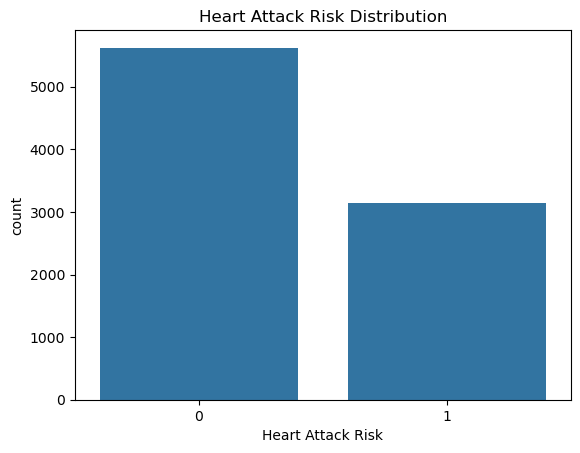


Training Size: (7010, 5)
Testing Size: (1753, 5)

Scaling Completed

Model Training Completed

Model Accuracy: 0.4940102681118083

Confusion Matrix:
 [[559 566]
 [321 307]]


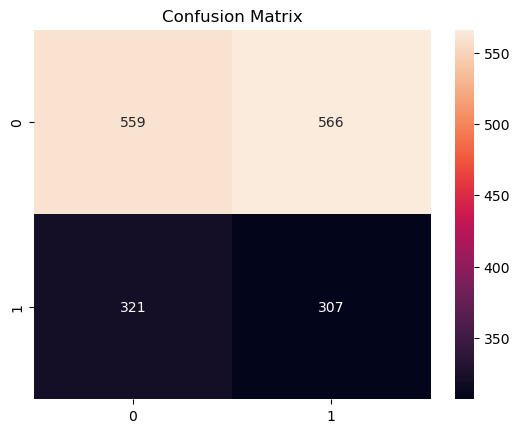


Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.50      0.56      1125
           1       0.35      0.49      0.41       628

    accuracy                           0.49      1753
   macro avg       0.49      0.49      0.48      1753
weighted avg       0.53      0.49      0.50      1753


✅ Model & Scaler Saved Successfully

Sample Prediction:
Risk Probability: 0.49
✅ Low Heart Attack Risk

🎉 COMPLETE ML PIPELINE FINISHED


C:\Users\sasik_pbd7hat\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [60]:
# =====================================================
# HEART ATTACK RISK PREDICTION - COMPLETE PIPELINE
# =====================================================

# ===== STEP 1: IMPORT LIBRARIES =====
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("✅ Libraries Loaded")

# ===== STEP 2: LOAD DATASET =====
data = pd.read_csv("heart_attack_prediction_dataset.csv")
print("\nDataset Loaded Successfully")

# ===== STEP 3: VIEW DATA =====
print("\nFirst 5 Rows:")
print(data.head())

print("\nColumns:")
print(data.columns)

# ===== STEP 4: SELECT IMPORTANT FEATURES =====
data = data[[
    "Age",
    "Cholesterol",
    "Heart Rate",
    "BMI",
    "Stress Level",
    "Heart Attack Risk"
]]

print("\nSelected Features:")
print(data.head())

# ===== STEP 5: CHECK MISSING VALUES =====
print("\nMissing Values:")
print(data.isnull().sum())

# ===== STEP 6: VISUALIZE TARGET VARIABLE =====
sns.countplot(x="Heart Attack Risk", data=data)
plt.title("Heart Attack Risk Distribution")
plt.show()

# ===== STEP 7: SPLIT FEATURES & TARGET =====
X = data.drop("Heart Attack Risk", axis=1)
y = data["Heart Attack Risk"]

# ===== STEP 8: TRAIN TEST SPLIT =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Size:", X_train.shape)
print("Testing Size:", X_test.shape)

# ===== STEP 9: FEATURE SCALING =====
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nScaling Completed")

# ===== STEP 10: TRAIN MODEL =====
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

print("\nModel Training Completed")

# ===== STEP 11: MAKE PREDICTIONS =====
y_pred = model.predict(X_test)

# ===== STEP 12: ACCURACY =====
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

# ===== STEP 13: CONFUSION MATRIX =====
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

# ===== STEP 14: CLASSIFICATION REPORT =====
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ===== STEP 15: SAVE MODEL & SCALER =====
pickle.dump(model, open("heart_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("\n✅ Model & Scaler Saved Successfully")

# ===== BONUS STEP: TEST NEW PATIENT =====
sample_patient = np.array([[65, 300, 170, 32, 9]])
sample_patient = scaler.transform(sample_patient)

prediction = model.predict(sample_patient)
probability = model.predict_proba(sample_patient)[0][1]

print("\nSample Prediction:")
print("Risk Probability:", round(probability,2))

if prediction[0] == 1:
    print("⚠️ High Heart Attack Risk")
else:
    print("✅ Low Heart Attack Risk")

# =====================================================
print("\n🎉 COMPLETE ML PIPELINE FINISHED")
# =====================================================